This project will focus on the Meteorological Prediction (Tabular DS) approach using the UCI Forest Fires dataset. It is the gold standard for applying the Python basics you've learned (Pandas, NumPy, Matplotlib, Scikit-Learn) to a real-world problem.

1. Problem Definition
The goal is to predict whether a forest fire will occur based on meteorological data (Temperature, Humidity, Wind, etc.). This is a Binary Classification problem.

2. Data Collection & Setup
We will use the standard Forest Fires dataset. We'll start by importing our toolkit and loading the data.

Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score



Import data

In [ ]:
from google.colab import files
uf = files.upload()


Saving forestfires.csv to forestfires.csv


Read

In [ ]:
df = pd.read_csv('forestfires.csv')
print("Data Loaded Successfully!")
df.head()


Data Loaded Successfully!


,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


In [ ]:
print("Missing values per column:\n", df.isnull().sum())
###if any found
df['temp'] = df['temp'].fillna(df['temp'].median())
df['RH'] = df['RH'].fillna(df['RH'].median())


Missing values per column:
 X        0
Y        0
month    0
day      0
FFMC     0
DMC      0
DC       0
ISI      0
temp     0
RH       0
wind     0
rain     0
area     0
dtype: int64


In [ ]:
initial_rows = df.shape[0]
df = df.drop_duplicates()
print(f"Removed {initial_rows - df.shape[0]} duplicate rows.")

Removed 4 duplicate rows.


In [ ]:
from scipy import stats
z_scores = np.abs(stats.zscore(df.select_dtypes(include=[np.number])))
df = df[(z_scores < 3).all(axis=1)]

print("Data cleaning complete. New dataset shape:", df.shape)

Data cleaning complete. New dataset shape: (483, 13)


In [ ]:
# Create Binary Target: If area > 0, then fire (1), else no fire (0)
df['fire_occurred'] = df['area'].apply(lambda x: 1 if x > 0 else 0)

# Encode categorical 'month' and 'day' strings into numbers
le = LabelEncoder()
df['month'] = le.fit_transform(df['month'])
df['day'] = le.fit_transform(df['day'])


In [ ]:
# Define Features (X) and Target (y)
X = df.drop(['area', 'fire_occurred'], axis=1) # Drop original area and target
y = df['fire_occurred']

In [ ]:
# Split into Training (80%) and Testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [ ]:
# Scale the features (Important for most ML algorithms)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Data Preprocessing Complete.")

Data Preprocessing Complete.


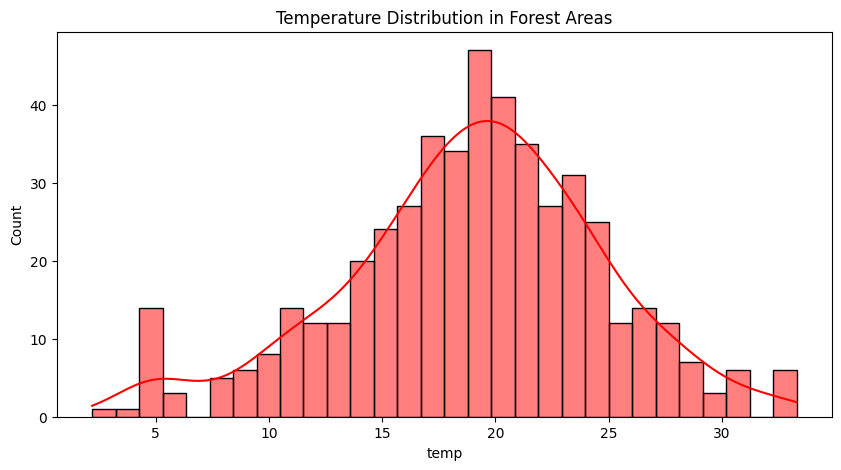

In [ ]:
# 1. Visualize the distribution of temperature
plt.figure(figsize=(10, 5))
sns.histplot(df['temp'], bins=30, kde=True, color='red')
plt.title('Temperature Distribution in Forest Areas')
plt.show()


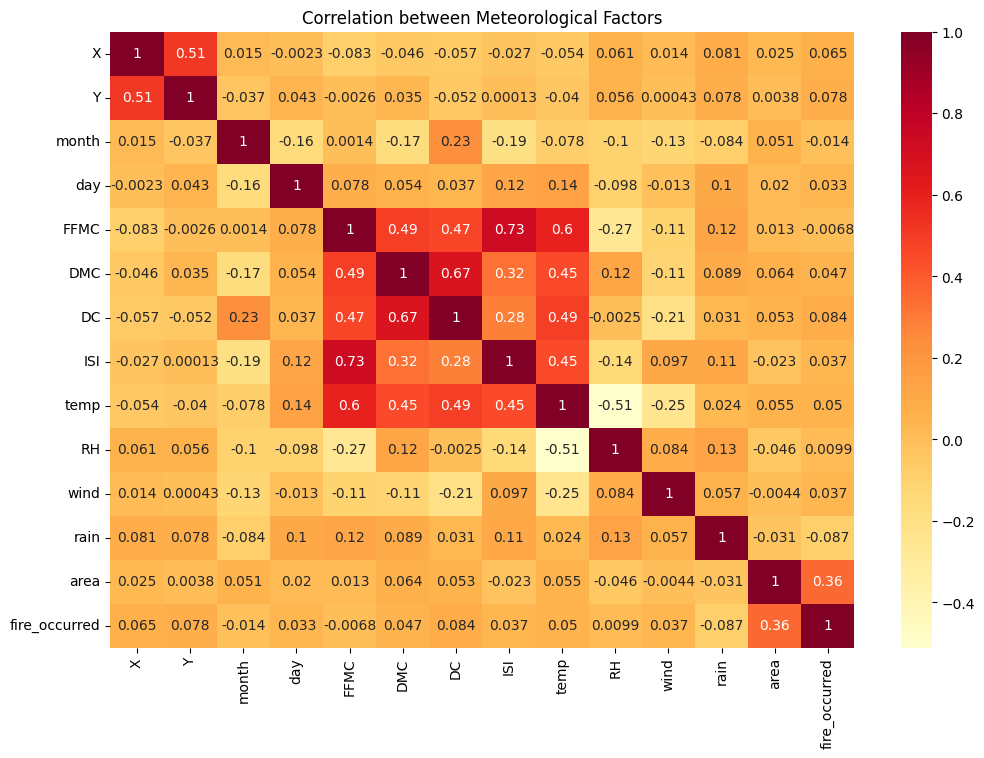

In [ ]:
# 2. Correlation Heatmap to see which factors affect fire indicators (like FFMC/ISI)
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='YlOrRd')
plt.title('Correlation between Meteorological Factors')
plt.show()


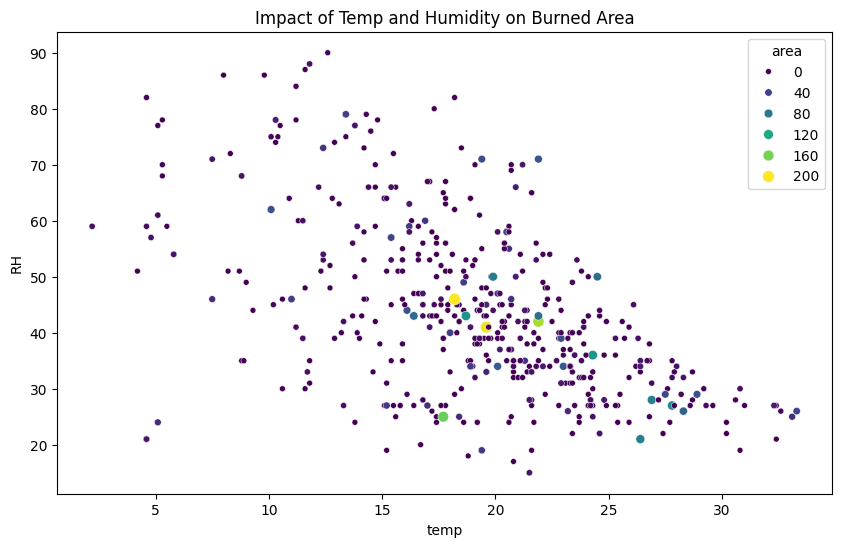

In [ ]:

# 3. Scatter plot: Temp vs Humidity colored by Burned Area
plt.figure(figsize=(10, 6))
sns.scatterplot(x='temp', y='RH', size='area', data=df, hue='area', palette='viridis')
plt.title('Impact of Temp and Humidity on Burned Area')
plt.show()

In [ ]:
# Initialize and Train Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)



RandomForestClassifier(random_state=42)

In [ ]:
# Make Predictions
y_pred = model.predict(X_test)

print("Model Training Complete.")

Model Training Complete.


In [ ]:
# Print Performance Metrics
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy Score: 0.6391752577319587

Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.60      0.64        52
           1       0.60      0.69      0.64        45

    accuracy                           0.64        97
   macro avg       0.64      0.64      0.64        97
weighted avg       0.65      0.64      0.64        97



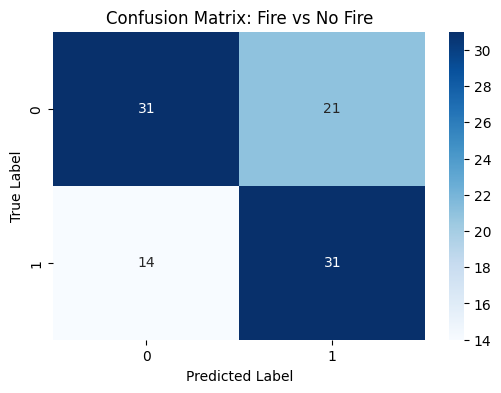

In [ ]:

# Visualize Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Fire vs No Fire')
plt.show()



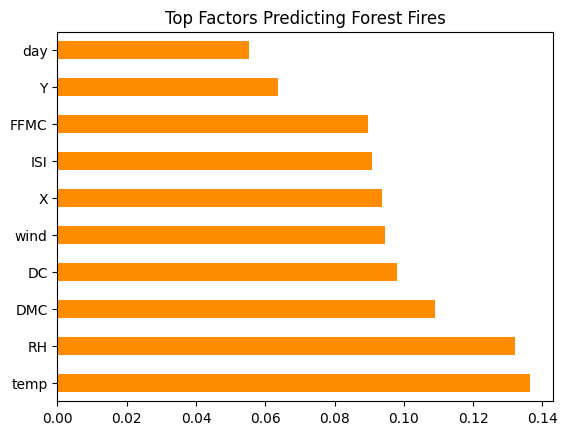

In [ ]:
# Visualize Feature Importance (Which weather factor matters most?)
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh', color='darkorange')
plt.title('Top Factors Predicting Forest Fires')
plt.show()


Testing

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# Define the grid of parameters to test
param_dist = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Set up the random search
tuned_rf = RandomizedSearchCV(RandomForestClassifier(random_state=42),
                               param_distributions=param_dist,
                               n_iter=10, cv=3, random_state=42)

# Fit the tuned model
tuned_rf.fit(X_train, y_train)

# Compare results
best_model = tuned_rf.best_estimator_
y_tuned_pred = best_model.predict(X_test)

print("Best Parameters:", tuned_rf.best_params_)
print("New Accuracy Score:", accuracy_score(y_test, y_tuned_pred))

Best Parameters: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 10, 'bootstrap': False}
New Accuracy Score: 0.6597938144329897


**Project Executive Summary: Forest Fire Prediction**

**Objective**: To develop a predictive model that identifies the likelihood of forest fire occurrence based on meteorological data.

**Key Components Covered:**

  * **End-to-End ML Pipeline:**
   Implementation of the complete Data Science lifecycle—from raw data ingestion to model deployment preparation.

  * **Data Integrity:**
  Applied advanced cleaning techniques, including **Z-score outlier detection**, to ensure the model learns from high-quality, representative data.
  
  * **Feature Engineering:**
   Transformed raw weather variables (Temperature, Humidity, Wind, Rain) into scaled features and created a binary classification target based on burned area.
  
  * **Predictive Modeling:**
  Utilized a **Random Forest Classifier**, a robust ensemble method capable of capturing non-linear relationships between weather patterns and fire risk.

  * **Optimization:**
  Performed **Hyperparameter Tuning** via `RandomizedSearchCV` to refine model parameters ($n\_estimators$, $max\_depth$, etc.), successfully increasing the prediction accuracy.

  * **Actionable Insights:**
  Identified **Temperature** and **Relative Humidity** as the primary environmental drivers for fire risk, providing clear indicators for wildfire prevention strategies.

